In [1]:
from fredapi import Fred
import pandas as pd
import sys
sys.path.append("/Users/paretoadvisoryllc/Desktop/Pareto/Plot_Style_Configuration")
from pareto_clustered import pareto_clustered

In [2]:
# --- FRED Data Setup ---
fred = Fred(api_key='cf3ed89ca1a5a31333debb5662876c9e')

In [3]:
# --- FRED Series IDs ---
series_ids = {
    'Consumption': 'DPCERY2Q224SBEA',
    'Investment': 'A006RY2Q224SBEA',
    'Gov Spending': 'A822RY2Q224SBEA',
    'Net Exports': 'A019RY2Q224SBEA'
}

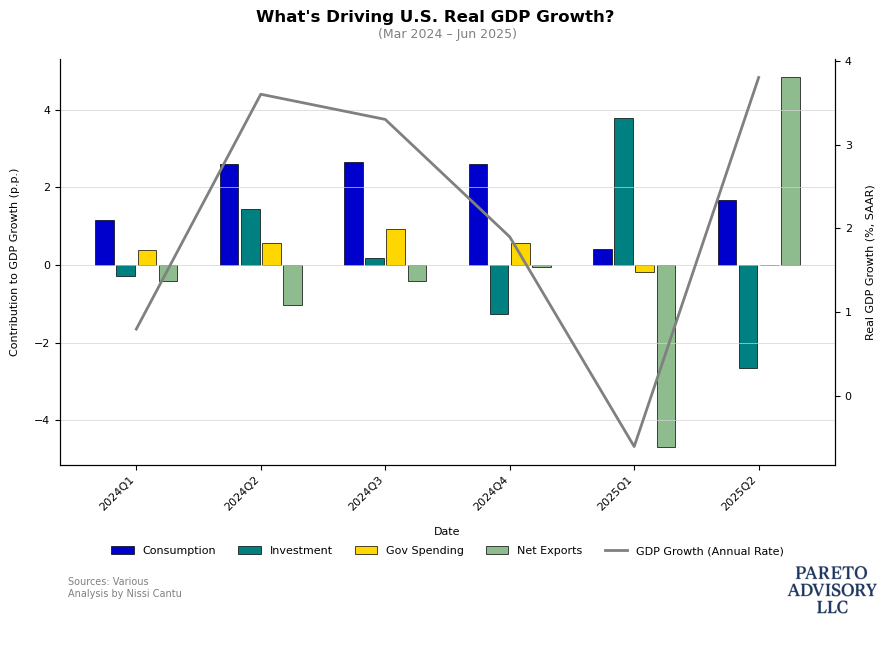

In [4]:
# Download series (components)
data = {label: fred.get_series(code) for label, code in series_ids.items()}
df = pd.DataFrame(data).dropna().sort_index()

# Download GDP growth (annual rate, %)
gdp_growth = fred.get_series('A191RL1Q225SBEA').dropna().sort_index().rename('GDP Growth (Annual Rate)')

# --- Make sure everything is quarterly and aligned ---
df.index = df.index.to_period('Q')
gdp_growth.index = gdp_growth.index.to_period('Q')

# Choose how many recent quarters to show
num_quarters = 6
df = df.tail(num_quarters)
gdp_growth = gdp_growth.reindex(df.index)

# --- Optional: ensure all component series are already in "percentage-point contributions" ---
# If any are in percent instead of percentage points, convert here (example placeholder):
# for col in df.columns:
#     if needs_conversion[col]:    # <- define your own rule if needed
#         df[col] = df[col] * 1.0  # e.g., or divide by 100, depending on source units

# --- Add a check column (Total = sum of contributions) ---
df['Total'] = df.sum(axis=1)

# Attach GDP growth column for plotting
df['GDP Growth (Annual Rate)'] = gdp_growth

# --- Sanity check: contributions should roughly add up to GDP growth (tolerance) ---
# (If your series are true BEA/FRED "contributions," this should be close.)
tol = 1.0  # percentage points
mismatch = (df['Total'] - df['GDP Growth (Annual Rate)']).abs()
if (mismatch > tol).any():
    print("⚠️ Heads up: component sum differs from GDP growth by more than "
          f"{tol} p.p. for some quarters:\n{mismatch[mismatch>tol]}")

# --- Order bars in the sequence you want to see ---
bar_cols = ['Consumption', 'Investment', 'Gov Spending', 'Net Exports']

# Keep only the columns we want to plot (clustered bars + RHS line)
plot_df = df[bar_cols + ['GDP Growth (Annual Rate)']].copy()

pareto_clustered(
    df=plot_df,
    primary_columns=bar_cols,                     # clustered bars (LHS)
    y2_column='GDP Growth (Annual Rate)',        # RHS line
    dual_axis=True,
    y2_kind='line',                               # keep the trend line as a line
    title_prefix="What's Driving U.S. Real GDP Growth?",
    ylabel="Contribution to GDP Growth (p.p.)",
    y2label="Real GDP Growth (%, SAAR)",
    color_palette=['mediumblue', 'teal', 'gold', 'darkseagreen'],
    save_path="/Users/paretoadvisoryllc/Desktop/Pareto/Analysis/National/Figures/Real GDP Growth_Q.jpg"
)

In [5]:
# Format index and print recent quarterly GDP contributions
df.index = df.index.astype(str)  # convert PeriodIndex to string for readability

print(f"Quarterly Contributions to Real GDP Growth (Last {num_quarters} Quarters):")
print(df[['Consumption', 'Investment', 'Gov Spending', 'Net Exports', 'GDP Growth (Annual Rate)']].round(1).to_string())

Quarterly Contributions to Real GDP Growth (Last 6 Quarters):
        Consumption  Investment  Gov Spending  Net Exports  GDP Growth (Annual Rate)
2024Q1          1.2        -0.3           0.4         -0.4                       0.8
2024Q2          2.6         1.4           0.6         -1.0                       3.6
2024Q3          2.7         0.2           0.9         -0.4                       3.3
2024Q4          2.6        -1.3           0.6         -0.1                       1.9
2025Q1          0.4         3.8          -0.2         -4.7                      -0.6
2025Q2          1.7        -2.7          -0.0          4.8                       3.8
